##📌 EXTRACCIÓN

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [4]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [5]:
#revisando valores nulos
df.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


##🛠️ Pre procesamiento

✔️ Remover columnas irrelevantes

In [6]:
df = df.drop(columns=['CustomerID'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


✔️Limpieza previa

In [8]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

✔️ Verificación nuevamente de los valores nulos o vacios

In [9]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
for col in cols_to_fix:
  print(f"Valores unicos en la columna '{col}: {df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-'*50)

Valores unicos en la columna 'OnlineSecurity: 2'
['No' 'Yes']
--------------------------------------------------
Valores unicos en la columna 'OnlineBackup: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'DeviceProtection: 2'
['No' 'Yes']
--------------------------------------------------
Valores unicos en la columna 'TechSupport: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'StreamingTV: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'StreamingMovies: 2'
['No' 'Yes']
--------------------------------------------------


In [11]:
df.select_dtypes(include=['object']).columns.tolist()

['Churn',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

## 📊 EDA

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

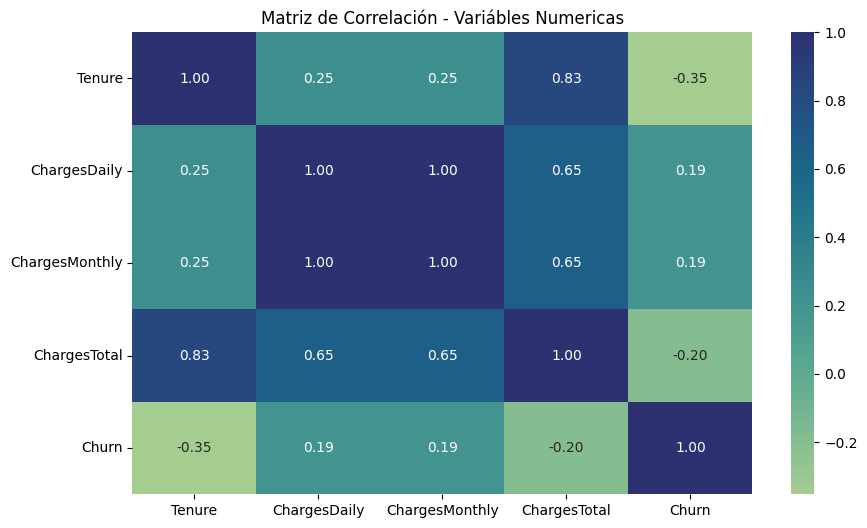

In [13]:
#obtengo las variables numericas
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="crest", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [14]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

In [15]:
df_numeric.head()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn
0,9,2.19,65.6,593.30,0
1,9,2.00,59.9,542.40,0
2,4,2.46,73.9,280.85,1
3,13,3.27,98.0,1237.85,1
4,3,2.80,83.9,267.40,1


✔️Analisis de churn por categoria (variables categoricas)



*   Seleccionar variables categoricas



In [16]:
#obtengo las variables categoricas
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols= categorical_cols.drop("Churn")



*   Tabla de proporción por categorías





In [17]:
for col in categorical_cols:
    print(f"\n*✦ Analisis de variable: {col}✦*")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


*✦ Analisis de variable: Gender✦*


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



*✦ Analisis de variable: SeniorCitizen✦*


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



*✦ Analisis de variable: Partner✦*


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



*✦ Analisis de variable: PaperlessBilling✦*


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



*✦ Analisis de variable: PaymentMethod✦*


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


🎯 Metodo recomendado: Qui-cuadrado (Chi-Square Test)
Hace  un ranking de los modelos que tiene más similitud con nuestra variable

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia al df
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols, #nombre de variable
    "Chi2 Score": chi_scores, #valor de similitud con el churn
    "p-value": p_values #el valor de confianza o porcentaje , cuán correcto está la máquina evaluando ese porcentaje.
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)
#Aquí a mí me dieron la idea también que parece más sencillo, podríamos hacer una ordenación utilizando y colocar una.
#1 25 minutos 8 segundos
#Una verificación que sea menor que 0.05. Esto sería otro modelo que podemos hacer esto.

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [19]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [20]:
#eliminando : "Gender", "PhoneService" , no tiene similittud con chunr
df = df.drop(columns=["Gender", "PhoneService"])

## 🎯 Split

In [21]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
#X son las variables que vamos a estar dando nuestros modelos para que ellos puedan entrenar y nos da la respuesta que es la Y que es hablar. De acuerdo con estas variables, este cliente va o no va a charlar.

2.Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,#balancea datos
    random_state=42
)

#Train entrenamos nuestro modelo, test lo usamos para comprobar si nuestro entrenamiento es válido.

3.One-Hot Encoding

In [23]:
# Aplicar One-Hot Encoding en train
X_train = pd.get_dummies(X_train, drop_first=True) #transforma a binarias

# Aplicar en test
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantizar que train y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [36]:
# Verificación de la proporción de cancelación
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [24]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

In [26]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1409 entries, 455 to 5658
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 1409 non-null   int64  
 1   ChargesMonthly                         1409 non-null   float64
 2   SeniorCitizen_Yes                      1409 non-null   bool   
 3   Partner_Yes                            1409 non-null   bool   
 4   Dependents_Yes                         1409 non-null   bool   
 5   MultipleLines_Yes                      1409 non-null   bool   
 6   InternetService_Fiber optic            1409 non-null   bool   
 7   InternetService_No                     1409 non-null   bool   
 8   OnlineSecurity_Yes                     1409 non-null   bool   
 9   OnlineBackup_Yes                       1409 non-null   bool   
 10  DeviceProtection_Yes                   1409 non-null   bool   
 11  TechSup

In [27]:
X_test.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
455,21,28.50,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
2301,11,111.40,True,False,False,True,True,False,False,True,True,True,True,True,False,False,True,False,True,False
2255,4,69.35,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
4527,5,19.95,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
3812,72,65.65,False,True,True,False,False,False,True,True,True,True,True,True,False,True,True,False,False,False


4. Verficicar desbalanceamiento

In [28]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


##Entrenamiento

Modelo 1 - Regresion Logística

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)#cantidad maxima de iteracion(entrenamiento)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("**************Regresion logistica*************")
print(classification_report(y_test, y_pred_log_normal))

**************Regresion logistica*************
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Modelo 2 — Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)#Cantidad de interacciones
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("*************Random Forest**************")
print(classification_report(y_test, y_pred_rf))

*************Random Forest**************
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [33]:
from sklearn.linear_model import LogisticRegression  #no es mejor modelo para churn

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



##Evaluación

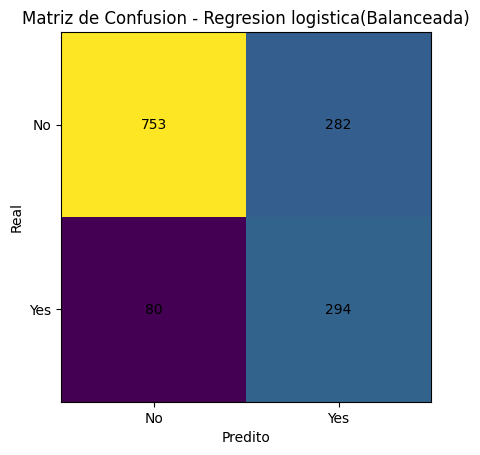

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

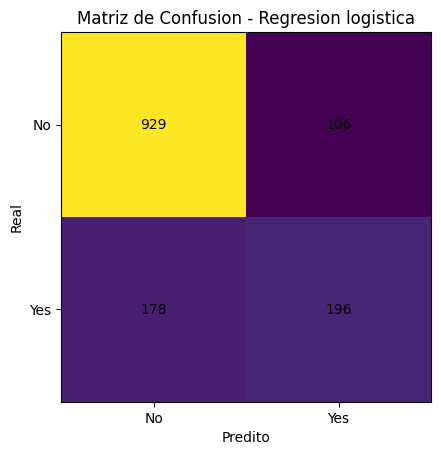

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica")
plt.xlabel("Predito")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

**📊 Variables más influyentes - Regresión Logística**

,Variable,Coeficiente
6,InternetService_Fiber optic,1.314570
12,StreamingTV_Yes,0.504591
18,PaymentMethod_Electronic check,0.429403
13,StreamingMovies_Yes,0.414177
5,MultipleLines_Yes,0.404301
16,PaperlessBilling_Yes,0.338989
2,SeniorCitizen_Yes,0.220128
10,DeviceProtection_Yes,0.088513
19,PaymentMethod_Mailed check,0.064071
17,PaymentMethod_Credit card (automatic),0.034919


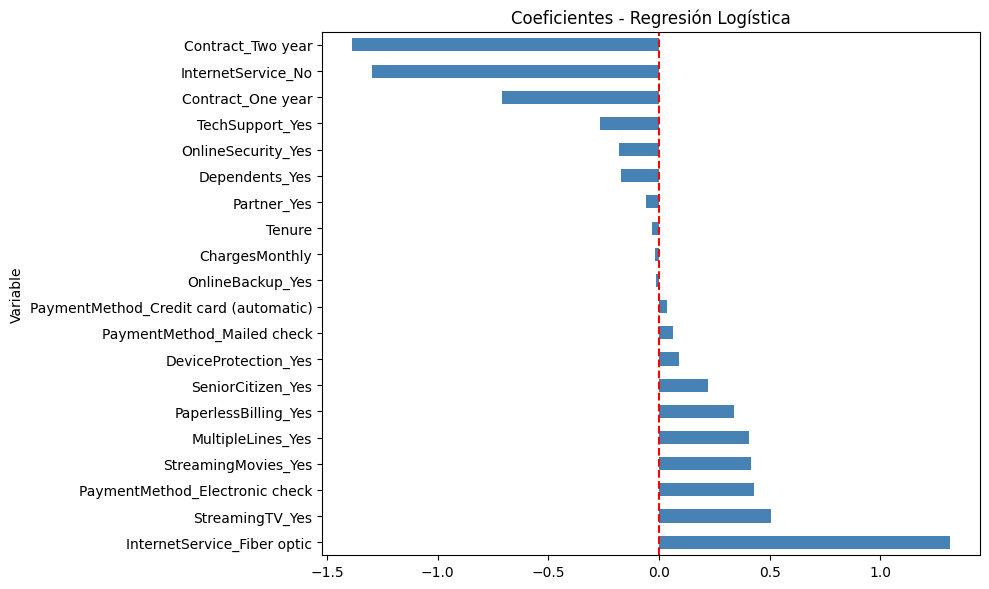

In [37]:
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt

# ── Coeficientes de la Regresión Logística ──
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model.coef_[0]
}).sort_values('Coeficiente', ascending=False)

display(Markdown("**📊 Variables más influyentes - Regresión Logística**"))
display(coef_df)

# Gráfico
plt.figure(figsize=(10, 6))
coef_df.set_index('Variable')['Coeficiente'].plot(kind='barh', color='steelblue')
plt.title('Coeficientes - Regresión Logística')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


Coeficiente POSITIVO (+) → esa variable AUMENTA probabilidad de churn

Coeficiente NEGATIVO (-) → esa variable REDUCE probabilidad de churn


**📊 Top 15 Variables más importantes - Random Forest**

,Variable,Importancia
1,ChargesMonthly,0.255088
0,Tenure,0.254962
6,InternetService_Fiber optic,0.046920
18,PaymentMethod_Electronic check,0.042238
15,Contract_Two year,0.041042
16,PaperlessBilling_Yes,0.030306
14,Contract_One year,0.029001
3,Partner_Yes,0.028666
8,OnlineSecurity_Yes,0.027619
9,OnlineBackup_Yes,0.027347


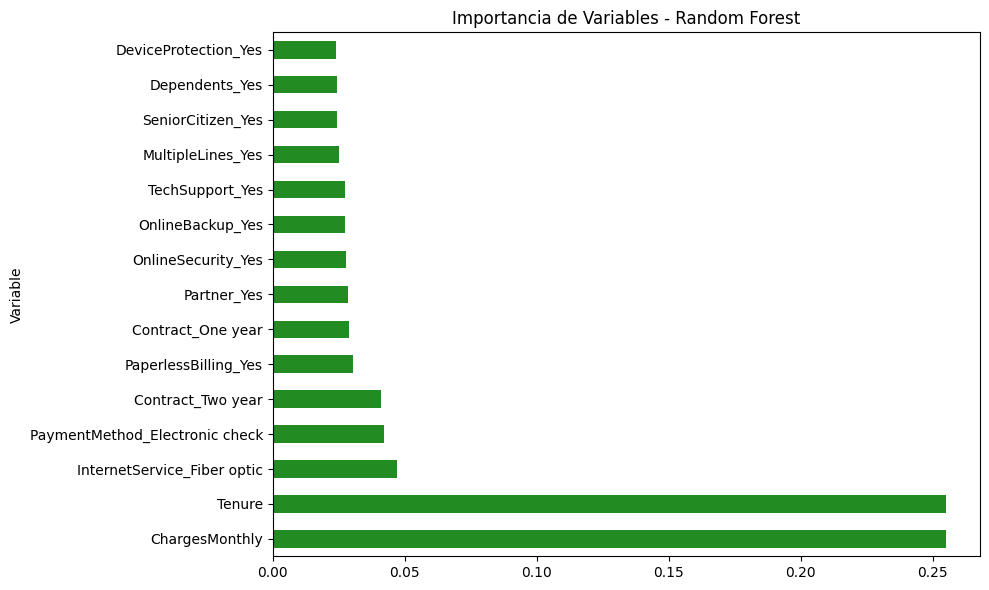

In [38]:
# ── Feature Importance del Random Forest ──
rf_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(15)

display(Markdown("**📊 Top 15 Variables más importantes - Random Forest**"))
display(rf_importance)

# Gráfico
plt.figure(figsize=(10, 6))
rf_importance.set_index('Variable')['Importancia'].plot(kind='barh', color='forestgreen')
plt.title('Importancia de Variables - Random Forest')
plt.tight_layout()
plt.show()


## 📋 Conclusión e Interpretación

### Factores principales de cancelación

Basado en los dos modelos entrenados, los factores que más
influyen en el churn de clientes en Telecom X son:

1. **Tipo de contrato** → Clientes Month-to-month cancelan
   ~43% vs ~3% en contratos Two year
2. **Método de pago** → Electronic check tiene la mayor tasa
   de cancelación (~45%)
3. **Tenure (antigüedad)** → Clientes nuevos (0-12 meses)
   son los más propensos a cancelar
4. **SeniorCitizen** → Adultos mayores cancelan ~42%
   vs ~24% en no seniors
5. **Servicios adicionales** → Clientes sin OnlineSecurity
   y TechSupport cancelan más

### Modelo seleccionado
La **Regresión Logística Balanceada** fue seleccionada como
modelo final por tener el mayor recall en churn (0.79),
lo que significa que detecta correctamente al 79% de los
clientes que cancelarán.

### Estrategias de retención recomendadas

| Problema detectado | Acción recomendada |
|---|---|
| Contratos mensuales | Ofrecer descuento para migrar a anual |
| Electronic check | Incentivar pago automático con beneficios |
| Clientes nuevos | Programa de onboarding primeros 3 meses |
| Senior Citizens | Plan especial con soporte dedicado |
| Sin servicios extra | Bundle de seguridad + soporte con descuento |
